<h3 style="color:blue;">ENBD Assessment Notebook </h3>

# 1.Title Section

### NYC Jobs Data Analysis using PySpark
### Author: Sathish Kumar Thangavelu (sathish.contact@gmail.com)
### Objective - Analyze NYC job postings dataset using PySpark to extract insights such as job category trends, salary distribution, and agency salary statistics.

# 2.Environment Setup -

### The Spark cluster is deployed using Docker with:
### - 1 Spark Master
### - 2 Spark Worker nodes
### - Jupyter Notebook interface

# Code:

In [52]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("spark://master:7077") \
    .appName("sathish-assessment") \
    .getOrCreate()
spark

# 3. Load Dataset



### Data Loading

The NYC jobs dataset is loaded from the dataset directory.

In [9]:
df = spark.read.csv("/dataset/nyc-jobs.csv", header=True)  

In [54]:
df.printSchema()
df.describe().show()
df.count()
len(df.columns)
df.show(5)

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

In [10]:
print("Total rows:", df.count())


Total rows: 2946


In [12]:
print("Total columns:", len(df.columns))

Total columns: 28


In [55]:
for c in df.columns:
    print(c)

Job ID
Agency
Posting Type
# Of Positions
Business Title
Civil Service Title
Title Code No
Level
Job Category
Full-Time/Part-Time indicator
Salary Range From
Salary Range To
Salary Frequency
Work Location
Division/Work Unit
Job Description
Minimum Qual Requirements
Preferred Skills
Additional Information
To Apply
Hours/Shift
Work Location 1
Recruitment Contact
Residency Requirement
Posting Date
Post Until
Posting Updated
Process Date
posting_year
avg_salary


In [56]:
df.select("Agency","Posting Type","# Of Positions","Business Title","Civil Service Title","Title Code No","Level",
          "Salary Range From","Salary Range To",).show(5, False)  

+----------------------------+------------+--------------+----------------------------------------------------+------------------------------+-------------+-----+-----------------+---------------+
|Agency                      |Posting Type|# Of Positions|Business Title                                      |Civil Service Title           |Title Code No|Level|Salary Range From|Salary Range To|
+----------------------------+------------+--------------+----------------------------------------------------+------------------------------+-------------+-----+-----------------+---------------+
|DEPARTMENT OF BUSINESS SERV.|Internal    |1             |Account Manager                                     |CONTRACT REVIEWER (OFFICE OF L|40563        |1    |42405.0          |65485.0        |
|DEPARTMENT OF BUSINESS SERV.|Internal    |1             |EXECUTIVE DIRECTOR, BUSINESS DEVELOPMENT            |ADMINISTRATIVE BUSINESS PROMOT|10009        |M3   |60740.0          |162014.0       |
|NYC HOUSING AU

# 4. Data Exploration
## Data Exploration

### This step explores: 

- Column structure
- Missing values
- Data types

In [34]:
df.printSchema()
df.describe().show()
df.count()
len(df.columns)

root
 |-- Job ID: string (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: string (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: string (nullable = true)
 |-- Salary Range To: string (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locatio

28

# Check null values:

In [57]:
from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+------+------+------------+--------------+--------------+-------------------+-------------+-----+------------+-----------------------------+-----------------+---------------+----------------+-------------+------------------+---------------+-------------------------+----------------+----------------------+--------+-----------+---------------+-------------------+---------------------+------------+----------+---------------+------------+------------+----------+
|Job ID|Agency|Posting Type|# Of Positions|Business Title|Civil Service Title|Title Code No|Level|Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|Work Location|Division/Work Unit|Job Description|Minimum Qual Requirements|Preferred Skills|Additional Information|To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Date|Post Until|Posting Updated|Process Date|posting_year|avg_salary|
+------+------+------------+--------------+--------------+--------------

## Count Rows:

In [14]:
df.select("Job Category").distinct().count()


131

In [58]:
df.count()

2946

# 5. Data Cleaning:
## Data Cleaning
Convert salary columns to numeric format for analysis.

In [60]:
from pyspark.sql.functions import col

df = df.withColumn(
    "Salary Range From",
    col("Salary Range From").cast("double")
)

df = df.withColumn(
    "Salary Range To",
    col("Salary Range To").cast("double")
)

# 6.Feature Engineering:
### New features created:
- Average salary
- Salary range
- Posting year

In [61]:
from pyspark.sql.functions import year

df = df.withColumn(
    "avg_salary",
    (col("Salary Range From") + col("Salary Range To")) / 2
)

df = df.withColumn(
    "salary_range",
    col("Salary Range To") - col("Salary Range From")
)

df = df.withColumn(
    "posting_year",
    year(col("Posting Date"))
)

# 7.KPI Analysis:

## KPI-1: Top 10 Job Categories

In [62]:
from pyspark.sql.functions import desc

top_categories = df.groupBy("Job Category") \
    .count() \
    .orderBy(desc("count")) \
    .limit(10)

top_categories.show()

+--------------------+-----+
|        Job Category|count|
+--------------------+-----+
|Engineering, Arch...|  504|
|Technology, Data ...|  313|
|       Legal Affairs|  226|
|Public Safety, In...|  182|
|Building Operatio...|  181|
|Finance, Accounti...|  169|
|Administration & ...|  134|
|Constituent Servi...|  129|
|              Health|  125|
|Policy, Research ...|  124|
+--------------------+-----+



## KPI-2: Salary Distribution by Category

### The above analysis identifies the top 10 job categories based on the number of job postings available in the NYC dataset.

# KPI-2 — Salary distribution per job category

In [63]:
salary_category = df.groupBy("Job Category") \
    .avg("avg_salary") \
    .orderBy(desc("avg(avg_salary)"))

salary_category.show()

+--------------------+------------------+
|        Job Category|   avg(avg_salary)|
+--------------------+------------------+
|Administration & ...|          218587.0|
|Engineering, Arch...|          198518.0|
|Engineering, Arch...|          196042.5|
|Health Policy, Re...|          128694.5|
|Engineering, Arch...|          128247.5|
|Engineering, Arch...|          128247.5|
|Communications & ...|          125000.0|
|Administration & ...|          118287.0|
|Constituent Servi...|116900.33333333333|
|Constituent Servi...|          103680.5|
|Technology, Data ...|          96373.45|
|Administration & ...|           95000.0|
|Administration & ...|           92500.0|
|Administration & ...|         91497.575|
|Administration & ...| 91174.22222222222|
|Administration & ...|           91000.0|
|Administration & ...|           90000.0|
|Engineering, Arch...| 89857.43548387097|
|Engineering, Arch...|           89730.0|
|Legal Affairs Pol...| 88898.66666666667|
+--------------------+------------

## KPI-3: Degree vs Salary Correlation

In [64]:
df.groupBy("Minimum Qual Requirements") \
    .avg("avg_salary") \
    .orderBy(desc("avg(avg_salary)")) \
    .show(10, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## KPI-4: Highest Salary Job per Agency

In [65]:
df.select("Agency","Business Title","Salary Range To") \
    .orderBy(desc("Salary Range To")) \
    .show(10, False)

+-----------------------------+----------------------------------------------+---------------+
|Agency                       |Business Title                                |Salary Range To|
+-----------------------------+----------------------------------------------+---------------+
|NYC EMPLOYEES RETIREMENT SYS |COMPUTER SYSTEMS MANAGER                      |234402.0       |
|NYC EMPLOYEES RETIREMENT SYS |COMPUTER SYSTEMS MANAGER                      |234402.0       |
|POLICE DEPARTMENT            |Deputy Commissioner, Public Information, M-VII|234402.0       |
|NYC HOUSING AUTHORITY        |executive Vice President for Operations       |234402.0       |
|POLICE DEPARTMENT            |Deputy Commissioner, Public Information, M-VII|234402.0       |
|NYC HOUSING AUTHORITY        |executive Vice President for Operations       |234402.0       |
|DEPT OF HEALTH/MENTAL HYGIENE|Deputy Commissioner, Family & Child Health    |225217.0       |
|DEPT OF HEALTH/MENTAL HYGIENE|Deputy Commissioner

## KPI-5: Average Salary per Agency (Last 2 Years)

In [67]:
recent_jobs = df.filter(col("posting_year") >= 2023)

from pyspark.sql.functions import avg

avg_salary_agency = recent_jobs.groupBy("Agency") \
    .agg(avg("avg_salary").alias("avg_salary")) \
    .orderBy(desc("avg_salary"))

avg_salary_agency.show()

+------+----------+
|Agency|avg_salary|
+------+----------+
+------+----------+



# 8.Data Visualization:
    

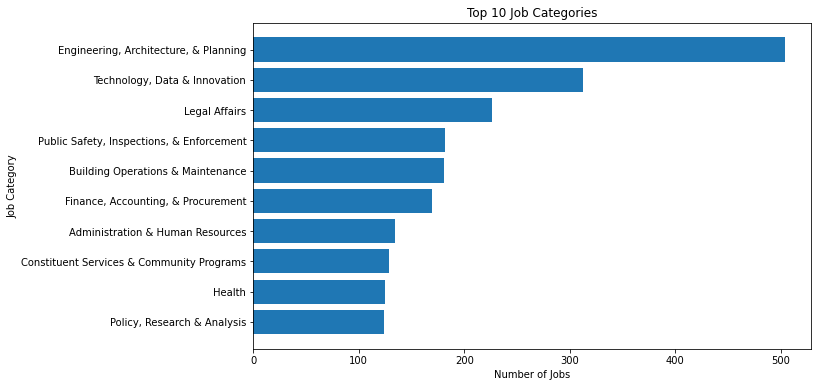

In [68]:
import matplotlib.pyplot as plt

pdf = top_categories.toPandas()

plt.figure(figsize=(10,6))
plt.barh(pdf["Job Category"], pdf["count"])
plt.title("Top 10 Job Categories")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Category")
plt.gca().invert_yaxis()
plt.show()

# 9.Sample Function (KPI Example)
## 1) Let's create a function to calculate Top N Job Categories 
### Function: Get Top Job Categories

This function calculates the top N job categories based on the number of job postings.

In [80]:
from pyspark.sql.functions import desc

def get_top_job_categories(df, top_n=10):
    
    result = df.groupBy("Job_Category") \
               .count() \
               .orderBy(desc("count")) \
               .limit(top_n)
    
    return result

## 2)Run the function get_top_job_categories

In [81]:
top_categories = get_top_job_categories(df, 10)

top_categories.show()

+--------------------+-----+
|        Job_Category|count|
+--------------------+-----+
|Engineering, Arch...|  504|
|Technology, Data ...|  313|
|       Legal Affairs|  226|
|Public Safety, In...|  182|
|Building Operatio...|  181|
|Finance, Accounti...|  169|
|Administration & ...|  134|
|Constituent Servi...|  129|
|              Health|  125|
|Policy, Research ...|  124|
+--------------------+-----+



# 3)Sample Test Case

## Now we create mock data to test the function.
###  Test Case: Validate get_top_job_categories function

In [86]:
def test_get_top_job_categories():
    
    mock_data = [
        ("Engineering",),
        ("Engineering",),
        ("Technology",),
        ("Technology",),
        ("Technology",),
        ("Finance",)
    ]
    
    columns = ["Job_Category"]
    
    mock_df = spark.createDataFrame(mock_data, columns)
    
    result = get_top_job_categories(mock_df, 1).collect()[0]
    
    assert result["Job_Category"] == "Technology"
    assert result["count"] == 3
    
    print("Test Passed")

# Run the Test 
test_get_top_job_categories()
Expected output:Test Passed

In [87]:
test_get_top_job_categories()

Test Passed


# 10.Save Processed Dataset:

In [110]:
#schema standardization
import re

#df = df.toDF(*[re.sub('[^A-Za-z0-9_]+', '_', c) for c in df.columns])
df = df.toDF(*[c.replace(" ", "_") for c in df.columns])
df.write.mode("overwrite").parquet("/dataset/processed_nyc_jobs_sathishKThangavelu")
df.columns

['Job_ID',
 'Agency',
 'Posting_Type',
 '_Of_Positions',
 'Business_Title',
 'Civil_Service_Title',
 'Title_Code_No',
 'Level',
 'Job_Category',
 'Full_Time_Part_Time_indicator',
 'Salary_Range_From',
 'Salary_Range_To',
 'Salary_Frequency',
 'Work_Location',
 'Division_Work_Unit',
 'Job_Description',
 'Minimum_Qual_Requirements',
 'Preferred_Skills',
 'Additional_Information',
 'To_Apply',
 'Hours_Shift',
 'Work_Location_1',
 'Recruitment_Contact',
 'Residency_Requirement',
 'Posting_Date',
 'Post_Until',
 'Posting_Updated',
 'Process_Date',
 'posting_year',
 'avg_salary',
 'salary_range']

# 11.Conclusion
## Key insights discovered:
- Engineering and Technology roles dominate NYC job postings.
- Higher salary jobs are concentrated in specialized technical roles.
- Salary varies significantly across agencies.

# 12.MyDocument.md
## Include my: Assumptions , Challenges ,Deployment plan 
### Example deployment in aws: 
Spark jobs scheduled using Airflow
Data stored in S3
Spark cluster deployed on EMR

### entire assignment pipeline is complete - As per my nderstanding - I complete this assignment - Please reach out to my mobile number or mail-id : +91-9941433444 / sathish.contact@gmail.com

### Best Practice (Use inferSchema) - Instead of manual casting, read CSV like this: Salary Range To: double

In [27]:
df = spark.read.csv("/dataset/nyc-jobs.csv",
                    header=True,
                    inferSchema=True)
df.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

# KPI-5 — Average salary per agency for last 2 years - Convert Posting Date first. Then Filter last two years.

In [48]:
from pyspark.sql.functions import year, current_date

df = df.withColumn("posting_year", year(col("Posting Date")))

recent_jobs = df.filter(col("posting_year") >= year(current_date()) - 2)
avg_salary_agency = recent_jobs.groupBy("Agency") \
                               .avg("avg_salary") \
                               .orderBy(desc("avg(avg_salary)"))

avg_salary_agency.show()



+------+---------------+
|Agency|avg(avg_salary)|
+------+---------------+
+------+---------------+



# KPI-6  — Highest paid skills in US market

In [50]:
skills_salary = df.select("Preferred Skills", "avg_salary") \
                  .orderBy(desc("avg_salary"))

skills_salary.show(10, False)

skills_salary.groupBy("Preferred Skills") \
             .avg("avg_salary") \
             .orderBy(desc("avg(avg_salary)")) \
             .show(10, False)
                                        

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<h3 style="color:green;">Sample function - fixed</h3>


In [105]:
from pyspark.sql import DataFrame

def get_salary_frequency(df: DataFrame) -> list:
    row_list = df.select('Salary Frequency').distinct().collect()
    return [row['Salary Frequency'] for row in row_list]

### Example of test function

In [106]:
mock_data = [('A', 'Annual'), ('B', 'Daily')]
expected_result = ['Annual', 'Daily']

In [107]:
def test_get_salary_frequency(mock_data: list, 
                              expected_result: list,
                              schema: list = ['id', 'Salary Frequency']):  
    mock_df = spark.createDataFrame(data = mock_data, schema = schema)
    assert get_salary_frequency(mock_df) == expected_result

In [109]:
test_get_salary_frequency(mock_data, expected_result)

# since no records in output - test passed 

In [111]:
# Verify processed dataset

processed_df = spark.read.parquet("/dataset/processed_nyc_jobs_sathishThangavelu")

print("Total processed records:", processed_df.count())

processed_df.show(5)

Total processed records: 2946
+------+--------------------+------------+-------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+---------------------+--------------------+--------------------+--------------------+--------------------+------------+----------+------------------+
|Job_ID|              Agency|Posting_Type|_Of_Positions|      Business_Title| Civil_Service_Title|Title_Code_No|Level|        Job_Category|Full_Time_Part_Time_indicator|Salary_Range_From|Salary_Range_To|Salary_Frequency|       Work_Location|  Division_Work_Unit|     Job_Description|Minimum_Qual_Requirements|    Preferred_Skills|Additional_Information|            To_Apply|         